In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [3]:
import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")
data_dir = os.path.join(path, "PlantVillage")

print("Data directory:", data_dir)
class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
print("Classes found:", len(class_names))
for cls in class_names:
    print(cls, "-", len(os.listdir(os.path.join(data_dir, cls))), "images")

Data directory: C:\Users\MERLIN J\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage
Classes found: 16
Pepper__bell___Bacterial_spot - 997 images
Pepper__bell___healthy - 1478 images
PlantVillage - 15 images
Potato___Early_blight - 1000 images
Potato___Late_blight - 1000 images
Potato___healthy - 152 images
Tomato_Bacterial_spot - 2127 images
Tomato_Early_blight - 1000 images
Tomato_Late_blight - 1909 images
Tomato_Leaf_Mold - 952 images
Tomato_Septoria_leaf_spot - 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite - 1676 images
Tomato__Target_Spot - 1404 images
Tomato__Tomato_YellowLeaf__Curl_Virus - 3209 images
Tomato__Tomato_mosaic_virus - 373 images
Tomato_healthy - 1591 images


In [6]:
IMG_SIZE = 96
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes
print("Classes:", train_generator.class_indices)

Found 33027 images belonging to 16 classes.
Found 8249 images belonging to 16 classes.
Classes: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'PlantVillage': 2, 'Potato___Early_blight': 3, 'Potato___Late_blight': 4, 'Potato___healthy': 5, 'Tomato_Bacterial_spot': 6, 'Tomato_Early_blight': 7, 'Tomato_Late_blight': 8, 'Tomato_Leaf_Mold': 9, 'Tomato_Septoria_leaf_spot': 10, 'Tomato_Spider_mites_Two_spotted_spider_mite': 11, 'Tomato__Target_Spot': 12, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 13, 'Tomato__Tomato_mosaic_virus': 14, 'Tomato_healthy': 15}


In [7]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,240 (1.76 MB)

 Trainable params: 459,280 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
os.makedirs("models", exist_ok=True)

EPOCHS = 10

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint("models/best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=150,
    validation_steps=50,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 820ms/step - accuracy: 0.4681 - loss: 1.7407
Epoch 1: val_accuracy improved from None to 0.69125, saving model to models/best_model.h5



Epoch 1: finished saving model to models/best_model.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.4681 - loss: 1.7407 - val_accuracy: 0.6913 - val_loss: 4.3975 - learning_rate: 0.0010
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4875 - loss: 1.4468
Epoch 2: val_accuracy did not improve from 0.69125
150/150 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.4875 - loss: 1.4468 - val_accuracy: 0.6913 - val_loss: 5.4918 - learning_rate: 0.0010
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.4909 - loss: 1.3554
Epoch 3: val_accuracy did not improve from 0.69125
150/150 ━━━━━━━━━━━━━━━━━━━━ 139s 931ms/step - accuracy: 0.4909 - loss: 1.3554 - val_accuracy: 0.6744 - val_loss: 3.0666 - learning_rate: 0.0010
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.5142 - loss: 1.2614
Epoch 4: val_accuracy did not improve from 0.69125
150/150 ━━━━━━━━━━━━━━━━━━━━ 140s 933ms/step - accuracy: 0.5142 - loss: 1.2614 - val_accuracy: 0.6900

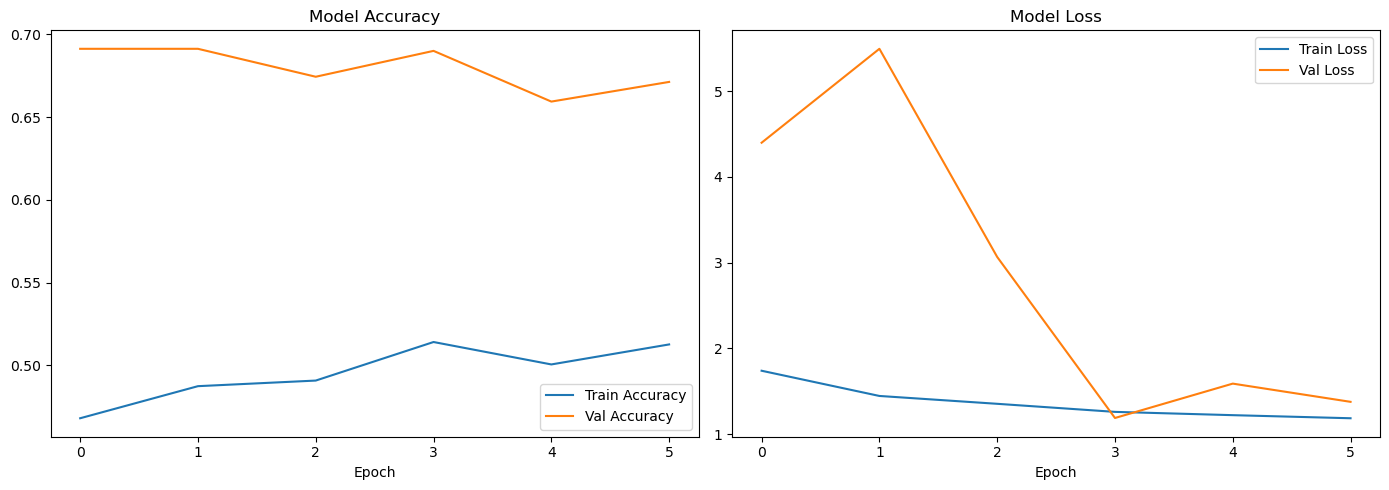

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.savefig("models/training_history.png")
plt.show()

258/258 ━━━━━━━━━━━━━━━━━━━━ 133s 510ms/step
Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.00      0.00      0.00       199
                     Pepper__bell___healthy       0.00      0.00      0.00       295
                               PlantVillage       0.50      1.00      0.67      4127
                      Potato___Early_blight       0.00      0.00      0.00       200
                       Potato___Late_blight       0.00      0.00      0.00       200
                           Potato___healthy       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.00      0.00      0.00       425
                        Tomato_Early_blight       0.00      0.00      0.00       200
                         Tomato_Late_blight       0.00      0.00      0.00       381
                           Tomato_Leaf_Mold       0.00      0.00      0.00      

C:\Users\MERLIN J\Downloads\anacoda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MERLIN J\Downloads\anacoda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MERLIN J\Downloads\anacoda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

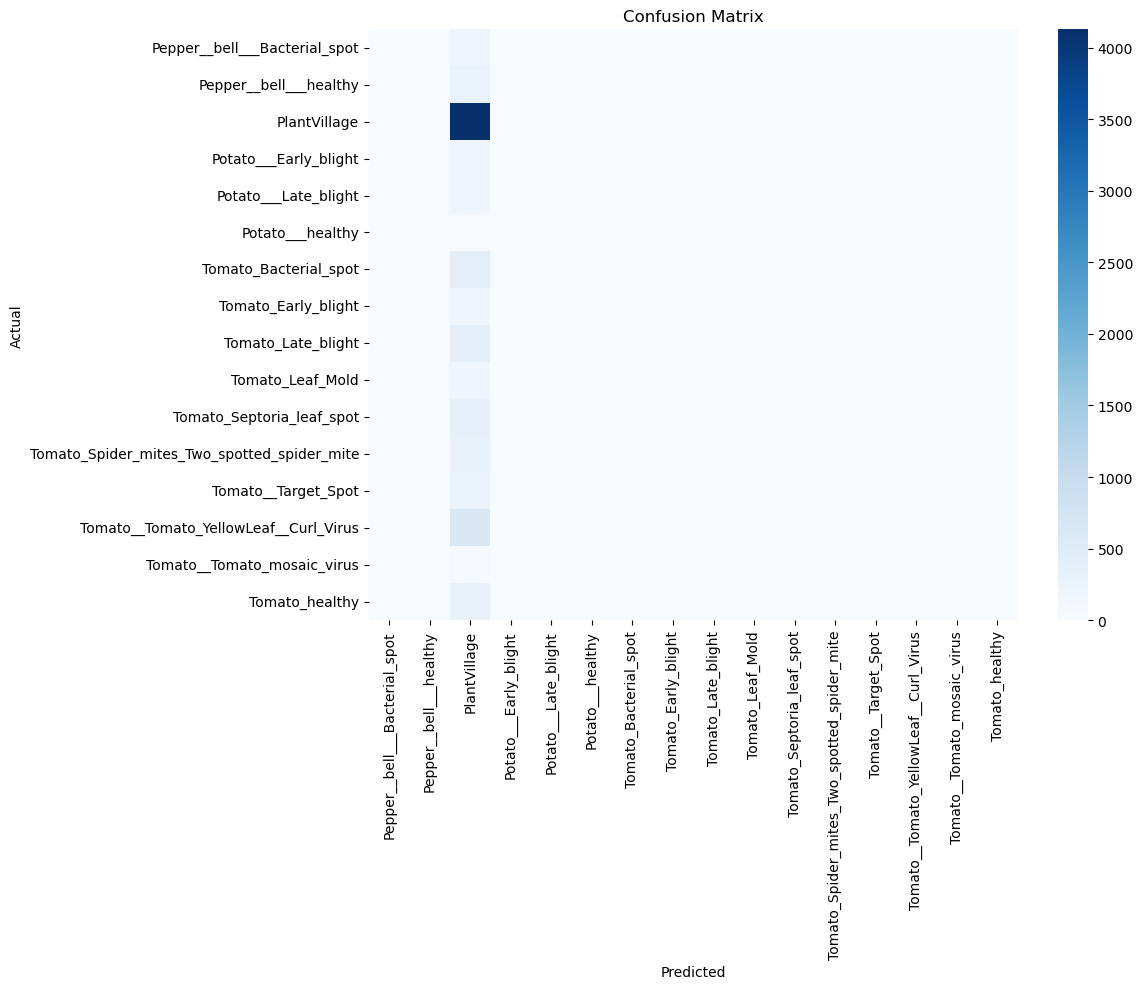

In [10]:
val_generator.reset()
predictions = model.predict(val_generator, steps=len(val_generator))
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes[:len(y_pred)]

class_labels = list(val_generator.class_indices.keys())

print("Classification Report:\n")
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

with open("models/performance_report.txt", "w") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("models/confusion_matrix.png")
plt.show()

In [11]:
model.save("models/plant_disease_model.h5")
print("Model saved to models/plant_disease_model.h5")

import json
with open("models/class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)
print("Class indices saved to models/class_indices.json")

Model saved to models/plant_disease_model.h5
Class indices saved to models/class_indices.json


Actual class: Tomato_Leaf_Mold
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step


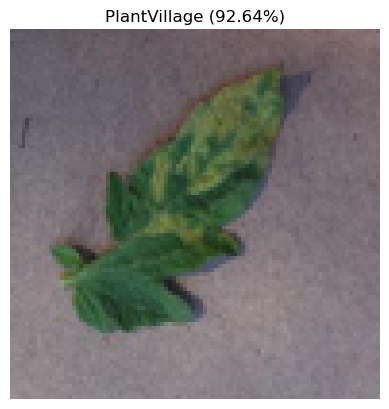

Predicted: PlantVillage (92.64% confidence)


In [12]:
def predict_disease(img_path, model, class_indices, img_size=IMG_SIZE):
    idx_to_class = {v: k for k, v in class_indices.items()}

    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = idx_to_class[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.imshow(img)
    plt.title(f"{pred_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    return pred_class, confidence

# Test it on a random sample image
test_cls = random.choice(class_names)
test_cls_path = os.path.join(data_dir, test_cls)
test_img = os.path.join(test_cls_path, random.choice(os.listdir(test_cls_path)))

print("Actual class:", test_cls)
predicted_class, confidence = predict_disease(test_img, model, train_generator.class_indices)
print(f"Predicted: {predicted_class} ({confidence:.2f}% confidence)")

In [14]:
dashboard_code = '''
import streamlit as st
import numpy as np
from PIL import Image
import json
import tensorflow as tf

st.set_page_config(page_title="Plant Disease Detector", page_icon="🌿", layout="centered")

IMG_SIZE = 96

@st.cache_resource
def load_model():
    model = tf.keras.models.load_model("models/plant_disease_model.h5")
    with open("models/class_indices.json", "r") as f:
        class_indices = json.load(f)
    idx_to_class = {v: k for k, v in class_indices.items()}
    return model, idx_to_class

model, idx_to_class = load_model()

st.title("🌿 Plant Disease Detection System")
st.write("Upload a leaf image and the model will predict whether the plant is healthy or diseased.")

uploaded_file = st.file_uploader("Choose a leaf image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_container_width=True)

    img_resized = image.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    with st.spinner("Analyzing leaf image..."):
        prediction = model.predict(img_array)
        pred_idx = np.argmax(prediction)
        pred_class = idx_to_class[pred_idx]
        confidence = np.max(prediction) * 100

    st.subheader("Prediction Result")

    if "healthy" in pred_class.lower():
        st.success(f"✅ {pred_class}")
    else:
        st.error(f"⚠️ {pred_class}")

    st.write(f"**Confidence:** {confidence:.2f}%")

    st.subheader("Top 3 Predictions")
    top_indices = prediction[0].argsort()[-3:][::-1]
    for idx in top_indices:
        st.write(f"- {idx_to_class[idx]}: {prediction[0][idx]*100:.2f}%")

st.markdown("---")
st.caption("Plant Disease Detection System | CNN Model trained on PlantVillage Dataset")
'''

import os
os.makedirs("dashboard", exist_ok=True)
with open("dashboard/app.py", "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print("Dashboard saved to dashboard/app.py")

Dashboard saved to dashboard/app.py


In [15]:
!pip install streamlit -q

In [4]:
import shutil

sample_dir = "sample_test_images"
os.makedirs(sample_dir, exist_ok=True)

sample_classes_to_test = random.sample(class_names, min(5, len(class_names)))

for cls in sample_classes_to_test:
    cls_path = os.path.join(data_dir, cls)
    img_file = random.choice(os.listdir(cls_path))
    src = os.path.join(cls_path, img_file)
    dst = os.path.join(sample_dir, f"{cls}_{img_file}")
    shutil.copy(src, dst)
    print(f"Copied: {dst}")

print(f"\nSample images saved in: {os.path.abspath(sample_dir)}")

Copied: sample_test_images\Tomato_Bacterial_spot_ef588b6e-ce90-4648-b1a4-990dc7dca22d___UF.GRC_BS_Lab Leaf 9288.JPG
Copied: sample_test_images\Tomato_Leaf_Mold_6fd472fe-cc75-4762-a3fa-2428649907c8___Crnl_L.Mold 7156.JPG
Copied: sample_test_images\Potato___Early_blight_24fb74df-0aa9-4e89-9ba4-55a4664438ab___RS_Early.B 8634.JPG
Copied: sample_test_images\Tomato__Tomato_mosaic_virus_b32647fc-d502-4bb4-99f6-3003874daee4___PSU_CG 2246.JPG
Copied: sample_test_images\Tomato_Septoria_leaf_spot_fe18d20c-3e3c-4fbf-9a11-c38228c6eb8e___JR_Sept.L.S 2623.JPG

Sample images saved in: C:\Users\MERLIN J\sample_test_images


In [ ]:
!streamlit run dashboard/app.py